In [1]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load variables from .env
load_dotenv()

# Access the token
hf_token = os.getenv("HF_TOKEN")
model_id = "meta-llama/Meta-Llama-3.1-8B"

c:\Users\User\Documents\TECHNION\semester 7\חיפוש מחקר\soudry\itay\k-v clustering\k_clustering\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# load model with original float16 weights
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    dtype=torch.float16, 
    device_map="cpu", # change to "cpu" for initial loading into system RAM to prevent crashing
    token=hf_token
)

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

: 

In [ ]:
import torch

# make sure the version contains the suffix+cu121
print(f"Version: {torch.__version__}") 

# make sure returns True
print(f"Is CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")

print(next(model.parameters()).device)

In [4]:
def get_W_K(heads, w_k_name):
    num_heads, head_dim, hidden_size = heads.shape # [8, 128, 4096]

    if w_k_name == "w_k1":
        return heads[0]

    elif w_k_name == "avg W_Ki":
        return torch.mean(heads, dim=0)

    elif w_k_name == "svd":
        wk_full = heads.reshape(-1, hidden_size) 
        U, S, Vh = torch.linalg.svd(wk_full, full_matrices=False)
        
        # We take the top 'head_dim' (128) singular values and vectors.
        # This is the "best possible" matrix of size 128x4096 
        # that represents the shared information of the full 1024x4096 matrix.
        k = head_dim 
        S_k = torch.diag(S[:k])
        Vh_k = Vh[:k, :]

        # We don't need U here because we want a representative 'Head' 
        # that lives in the same row-space (V) as the original weights.
        # The reference is constructed from the top 128 principal directions.
        svd_reference = S_k @ Vh_k # Resulting shape: [128, 4096]
        
        return svd_reference

    elif w_k_name == "svd (avg)":
        avg_head = torch.mean(heads, dim=0)
        # We use full_matrices=False for efficiency
        U, S, Vh = torch.linalg.svd(avg_head, full_matrices=False)
        
        # 3. Reconstruct using only the first singular value (Rank-1 Approximation)
        # This represents the "Principal Component" of the W_K projection
        # Formula: u_1 * s_1 * v_1^T
        s_1 = S[0]
        u_1 = U[:, 0:1]
        vh_1 = Vh[0:1, :]
        
        svd_reference = u_1 @ (s_1 * vh_1)
        return svd_reference

    elif w_k_name == "I":
        return torch.eye(head_dim, hidden_size)
    
    elif w_k_name == "0":
        return torch.zeros(head_dim, hidden_size)
    else:
        raise ValueError(f"Invalid W_K name: {w_k_name}")


In [5]:
import torch
import torch.nn as nn
from transformers import AutoModelForCausalLM, AutoTokenizer
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- Utility: Your existing A optimization function ---
def find_optimal_A_ls_sq(W_ki_raw, W_ref_raw):
    """
    Computes the optimal linear transformation A [128, 128]
    such that (W_ki_raw.T @ A) approximates W_ref_raw.T
    """
    W_ki = W_ki_raw.t().to(torch.float32)   # [4096, 128]
    W_ref = W_ref_raw.t().to(torch.float32)  # [4096, 128]
    
    W_ki_pinv = torch.linalg.pinv(W_ki)
    A_opt = W_ki_pinv @ W_ref # [128, 128]
    return A_opt.to(W_ki_raw.dtype)

# --- 1. Hook Container Class ---
class AttentionHookContainer:
    def __init__(self):
        self.q_out = {}      # Captured Q activations
        self.k_out = {}      # Captured K activations
        self.input_x = {}    # Captured real X (hidden states)

    def get_hook(self, layer_idx, name):
        def hook(module, input, output):
            if name == 'q':
                self.q_out[layer_idx] = output.detach()
            elif name == 'k':
                self.k_out[layer_idx] = output.detach()
                self.input_x[layer_idx] = input[0].detach() # Capture the real X
        return hook

# --- 2. Slicing Utilities (GQA Aware) ---
def get_q_from_hook(layer_idx, q_head_idx, hooks_container):
    # Llama 3.1 8B: 32 Q heads, each dim 128 (Total 4096)
    q_all = hooks_container.q_out[layer_idx]
    seq_len = q_all.shape[1]
    return q_all.view(seq_len, 32, 128)[:, q_head_idx, :]

def get_k_from_hook(layer_idx, k_head_idx, hooks_container):
    # Llama 3.1 8B: 8 K heads (GQA), each dim 128 (Total 1024)
    k_all = hooks_container.k_out[layer_idx]
    seq_len = k_all.shape[1]
    return k_all.view(seq_len, 8, 128)[:, k_head_idx, :]

# --- 3. RoPE Application (Architecture Specific) ---
def apply_rope_to_slice(q_slice, k_slice, layer_idx, model, device):
    """
    Applies the model's actual Rotary Positional Embedding logic.
    """
    rotary_emb = model.model.rotary_emb 
    seq_len = q_slice.shape[0]
    
    # Create position IDs [1, seq_len]
    position_ids = torch.arange(seq_len, device=device).unsqueeze(0)
    
    # Get cos/sin from the model's rotary_emb
    cos, sin = rotary_emb(k_slice.unsqueeze(0).transpose(1, 2), position_ids)
    
    # Apply rotation using the model's internal function
    from transformers.models.llama.modeling_llama import apply_rotary_pos_emb
    # apply_rotary_pos_emb expects [batch, num_heads, seq, dim]
    q_r, k_r = apply_rotary_pos_emb(q_slice.unsqueeze(0).unsqueeze(1), 
                                   k_slice.unsqueeze(0).unsqueeze(1), 
                                   cos, sin)
    
    return q_r.squeeze(), k_r.squeeze()

# --- 4. Main Divergence Analysis Function ---
def run_full_divergence_analysis(model, tokenizer, prompts, method="svd"):
    device = next(model.parameters()).device
    num_layers = len(model.model.layers)
    num_k_heads = 8
    
    results_linear = np.zeros((num_layers, num_k_heads))
    results_rope = np.zeros((num_layers, num_k_heads))
    
    hooks = AttentionHookContainer()
    handles = []
    
    # Register Hooks
    for i in range(num_layers):
        h_q = model.model.layers[i].self_attn.q_proj.register_forward_hook(hooks.get_hook(i, 'q'))
        h_k = model.model.layers[i].self_attn.k_proj.register_forward_hook(hooks.get_hook(i, 'k'))
        handles.extend([h_q, h_k])

    for prompt in prompts:
        inputs = tokenizer(prompt, return_tensors="pt").to(device)
        with torch.no_grad():
            model(**inputs)

        for l_idx in range(num_layers):
            #wk_full = model.model.layers[l_idx].self_attn.k_proj.weight.to(device)

            """param = model.model.layers[l_idx].self_attn.k_proj.weight
            if param.is_meta:
                wk_full = param.data.to(device) 
            else:
                wk_full = param.detach().to(device)"""

            """import accelerate

            param = model.model.layers[l_idx].self_attn.k_proj.weight
            with accelerate.init_empty_weights():
                wk_full = accelerate.utils.set_module_tensor_to_device(
                    model.model.layers[l_idx].self_attn.k_proj, "weight", device=device
                )
            wk_full = model.model.layers[l_idx].self_attn.k_proj.weight.data"""

            """model.model.layers[l_idx].self_attn.to(device)
            wk_full = model.model.layers[l_idx].self_attn.k_proj.weight.data"""

            k_proj_layer = model.model.layers[l_idx].self_attn.k_proj

            if k_proj_layer.weight.is_meta:
                from accelerate.utils import set_module_tensor_to_device
                k_proj_layer 

            wk_full = k_proj_layer.weight.data

            heads_weights = wk_full.view(8, 128, 4096).to(torch.float32)
            # calculated again for each prompt to save memory and not save all the W_K of each layer in the GPU, can change later
            
            W_K_shared = get_W_K(heads_weights, w_k_name=method).to(torch.float16)

            X = hooks.input_x[l_idx][0] # Real X: [seq, 4096]
            
            # Map Q heads to K heads (GQA: 4 Q heads per 1 K head)
            for k_idx in range(num_k_heads):
                # We analyze the first Q head of each K group
                q_idx = k_idx * 4 ### I think no tall Qs are used, only 1/4, later implement loop to check all Qs
                
                # A. Find Optimal A for weights
                W_ki = model.model.layers[l_idx].self_attn.k_proj.weight.data.reshape(8, 128, 4096)[k_idx].to(torch.float16)
                A_opt = find_optimal_A_ls_sq(W_ki, W_K_shared) # Your function
                A_corr = torch.linalg.pinv(A_opt.to(torch.float32)).t().to(device, dtype=torch.float16)

                ###to fix - go over all Qs, 
                ###for q_sub_idx in range(4):
                ###    q_idx = k_idx * 4 + q_sub_idx
                # B. Extract Original Activations
                q_orig = get_q_from_hook(l_idx, q_idx, hooks)
                k_orig = get_k_from_hook(l_idx, k_idx, hooks)

                # --- 1. Linear Test (No RoPE) ---
                H_orig = torch.matmul(q_orig, k_orig.t())
                
                q_fixed = q_orig @ A_corr
                k_shared = X @ W_K_shared.t()
                H_fixed = torch.matmul(q_fixed, k_shared.t())
                
                div_lin = (torch.norm(H_orig - H_fixed, p='fro')**2) / (torch.norm(H_orig, p='fro')**2)
                results_linear[l_idx, k_idx] += div_lin.item()

                # --- 2. RoPE Test ---  ### make sure apply_rope_to_slice func is correct 
                q_r_orig, k_r_orig = apply_rope_to_slice(q_orig, k_orig, l_idx, model, device)
                q_r_fixed, k_r_fixed = apply_rope_to_slice(q_fixed, k_shared, l_idx, model, device)
                
                H_rope_orig = torch.matmul(q_r_orig, k_r_orig.t())
                H_rope_fixed = torch.matmul(q_r_fixed, k_r_fixed.t())

                div_rope = (torch.norm(H_rope_orig - H_rope_fixed, p='fro')**2) / (torch.norm(H_rope_orig, p='fro')**2)
                results_rope[l_idx, k_idx] += div_rope.item()

    # Cleanup
    for h in handles: h.remove()
    
    return results_linear / len(prompts), results_rope / len(prompts)

In [6]:
# 1. Define a list of common/standard prompts
common_prompts = [
    #"The capital of France is Paris and the Eiffel Tower is located there.",
    "Solve the following math problem: If I have 3 apples and you give me 5 more, how many do I have?",
    #"Write a short Python function to sort a list of numbers."
]

# 2. Prepare your reference matrices (This is a placeholder for your W_K matrices)
# You should have one [128, 4096] matrix per layer.
# Example: w_k_ref_list = [layer_0_ref, layer_1_ref, ..., layer_31_ref]
#w_k_ref_list = prepare_w_k_ref_list(model, method="svd")


tokenizer = AutoTokenizer.from_pretrained(model_id, token=hf_token)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


# 3. Run the analysis
results_lin, results_rope = run_full_divergence_analysis(
    model=model, 
    tokenizer=tokenizer, 
    prompts=common_prompts, 
    method="svd"
)

# 4. Print a quick summary of the first layer
print(f"Layer 0 Linear Divergence: {results_lin[0].mean():.2%}")
print(f"Layer 0 RoPE Divergence: {results_rope[0].mean():.2%}")

Layer 0 Linear Divergence: nan%
Layer 0 RoPE Divergence: nan%


c:\Users\User\Documents\TECHNION\semester 7\חיפוש מחקר\soudry\itay\k-v clustering\k_clustering\venv\Lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
c:\Users\User\Documents\TECHNION\semester 7\חיפוש מחקר\soudry\itay\k-v clustering\k_clustering\venv\Lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)
c:\Users\User\Documents\TECHNION\semester 7\חיפוש מחקר\soudry\itay\k-v clustering\k_clustering\venv\Lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
c:\Users\User\Documents\TECHNION\semester 7\חיפוש מחקר\soudry\itay\k-v clustering\k_clustering\venv\Lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


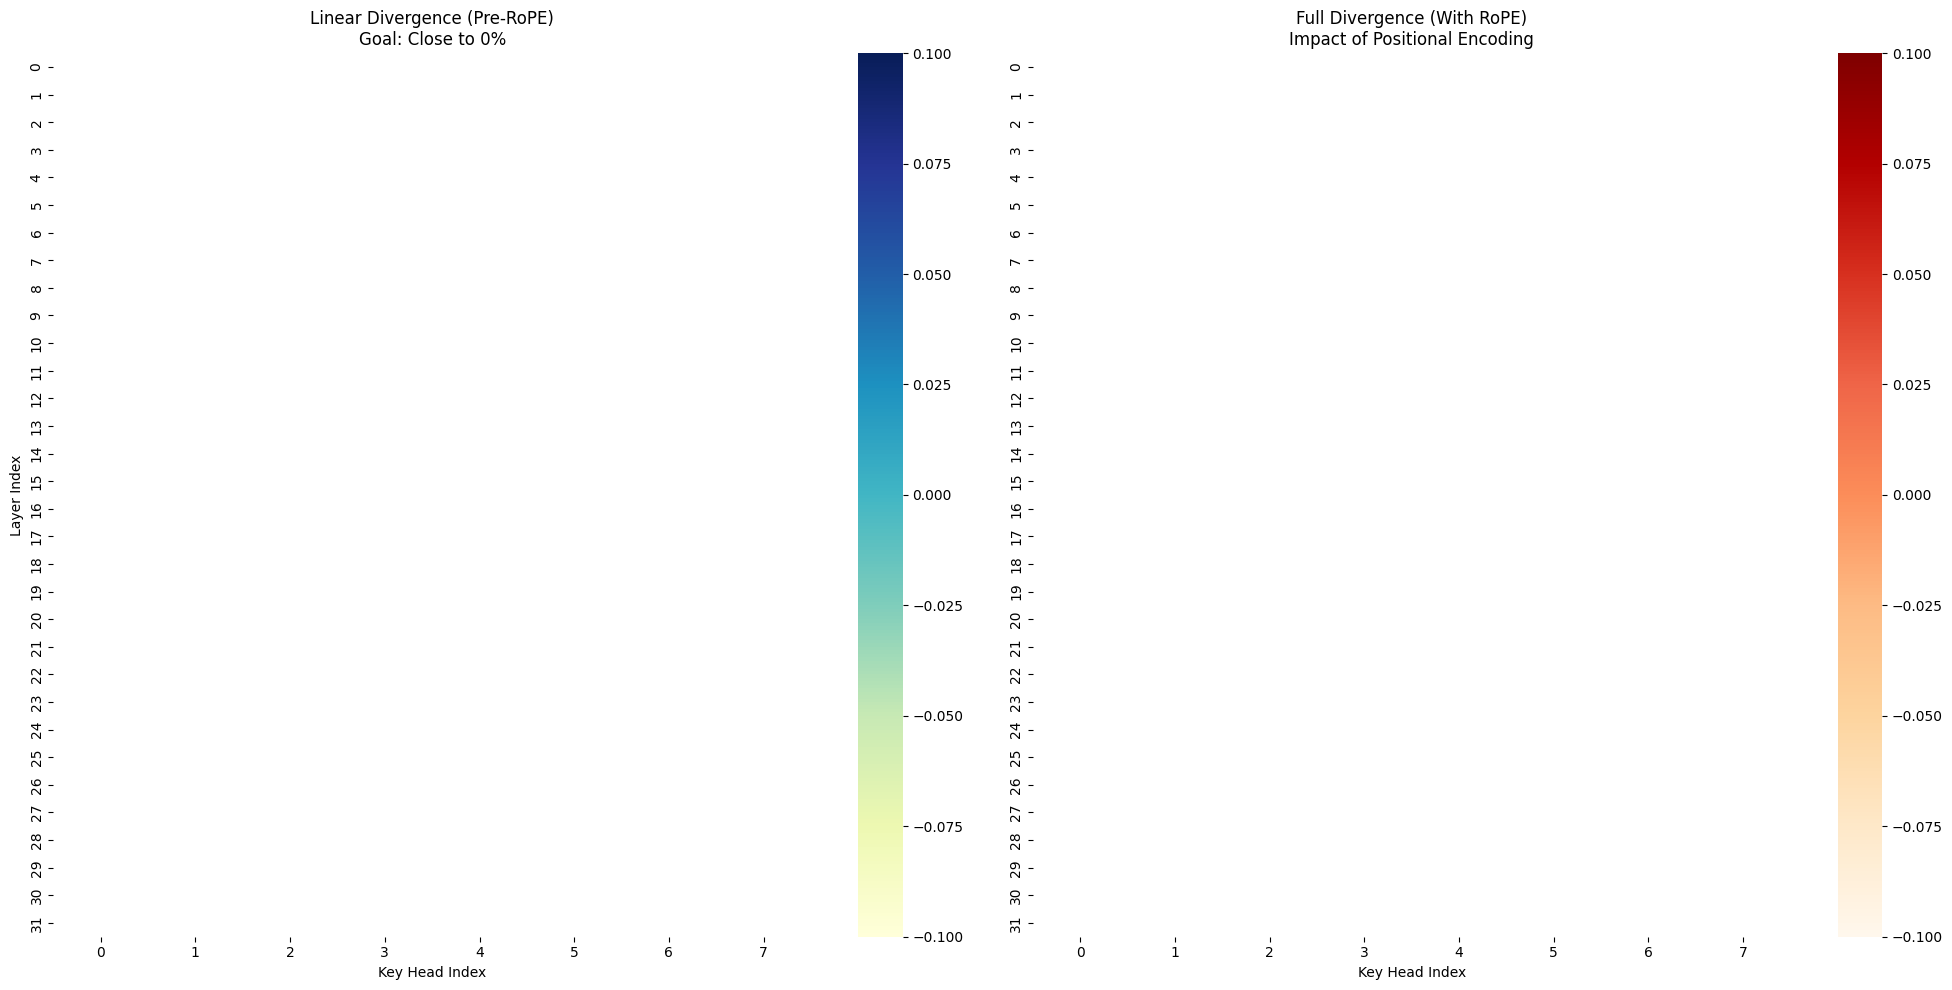

In [7]:
def plot_comparison(res_lin, res_rope):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
    
    sns.heatmap(res_lin, annot=False, cmap="YlGnBu", ax=ax1)
    ax1.set_title("Linear Divergence (Pre-RoPE)\nGoal: Close to 0%")
    ax1.set_xlabel("Key Head Index")
    ax1.set_ylabel("Layer Index")

    sns.heatmap(res_rope, annot=False, cmap="OrRd", ax=ax2)
    ax2.set_title("Full Divergence (With RoPE)\nImpact of Positional Encoding")
    ax2.set_xlabel("Key Head Index")
    
    plt.tight_layout()
    plt.show()

plot_comparison(results_lin, results_rope)